# Stance Detection: Opini Publik Indonesia Terhadap Kasus Kekerasan Seksual
**Dataset:** finalDataUNY.csv  
**Models:** IndoBERT Base | IndoBERTweet  
**Target:** stance (Neutral, Advocacy, Supportive, VictimBlaming)

## 1. SETUP  & PREPARATION DATA

In [25]:
lenfrom google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
!pip install transformers datasets evaluate accelerate scikit-learn seaborn matplotlib pandas PySastrawi emoji -q

In [27]:
import os, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import emoji

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    cohen_kappa_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import torch
from torch import nn
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)


np.random.seed(42)
torch.manual_seed(42)
print('Set Up Selesai')

Set Up Selesai


## 2. LOAD DATA

In [28]:
path = "/content/drive/MyDrive/Gemastik/DataFinal/finalDataUNY.csv"
data = pd.read_csv(path)
print('jumlah Baris dan Kolom pada data: ', data.shape)
data.head()

jumlah Baris dan Kolom pada data:  (1500, 2)


,text,stance
0,udh bener di UGM aja lah,Neutral
1,jurusan hukum ❎\npraktek hukum ✅,Neutral
2,"Ini masalah rusaknya moral, bukan hal yang sep...",Advocacy
3,DO aja semuanya,Advocacy
4,Usut tuntas proses hukum dan pecat mahasiswa b...,Advocacy


## 3. EDA (EXPLORATORY DATA ANALYSIS)

In [29]:
print('Info Dataset:')
data.info()
print()
print('Missing Values:')
print(data.isnull().sum())
print()
print('Duplicates Values:')
print(data.duplicated().sum())
print()
print('Distribusi Opini Publik:')
print(data['stance'].value_counts())

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    1500 non-null   object
 1   stance  1500 non-null   object
dtypes: object(2)
memory usage: 23.6+ KB

Missing Values:
text      0
stance    0
dtype: int64

Duplicates Values:
0

Distribusi Opini Publik:
stance
Neutral          1108
Advocacy          210
Supportive        129
VictimBlaming      53
Name: count, dtype: int64


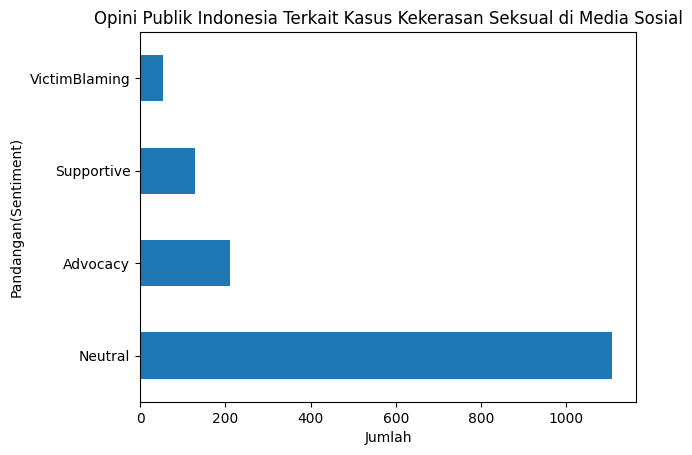

Jumlah Opini Publik Terhadap Kasus Kekerasan Seksual di Media Sosial stance
Neutral          1108
Advocacy          210
Supportive        129
VictimBlaming      53
Name: count, dtype: int64


In [30]:
hitungText = data['stance'].value_counts()

plt.figure()
hitungText.plot(kind = 'barh')
plt.title("Opini Publik Indonesia Terkait Kasus Kekerasan Seksual di Media Sosial")
plt.xlabel("Jumlah")
plt.ylabel("Pandangan(Sentiment)")
plt.show()

print("Jumlah Opini Publik Terhadap Kasus Kekerasan Seksual di Media Sosial",
      hitungText)

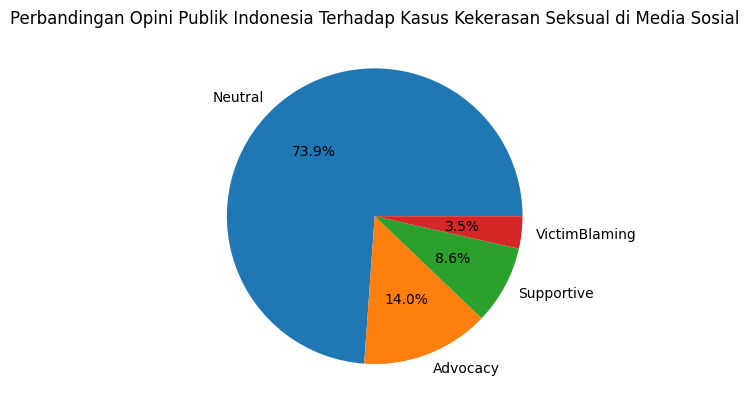

In [31]:
plt.figure()
hitungText.plot(kind='pie', autopct = '%1.1f%%')
plt.title("Perbandingan Opini Publik Indonesia Terhadap Kasus Kekerasan Seksual di Media Sosial")
plt.ylabel('')
plt.show()

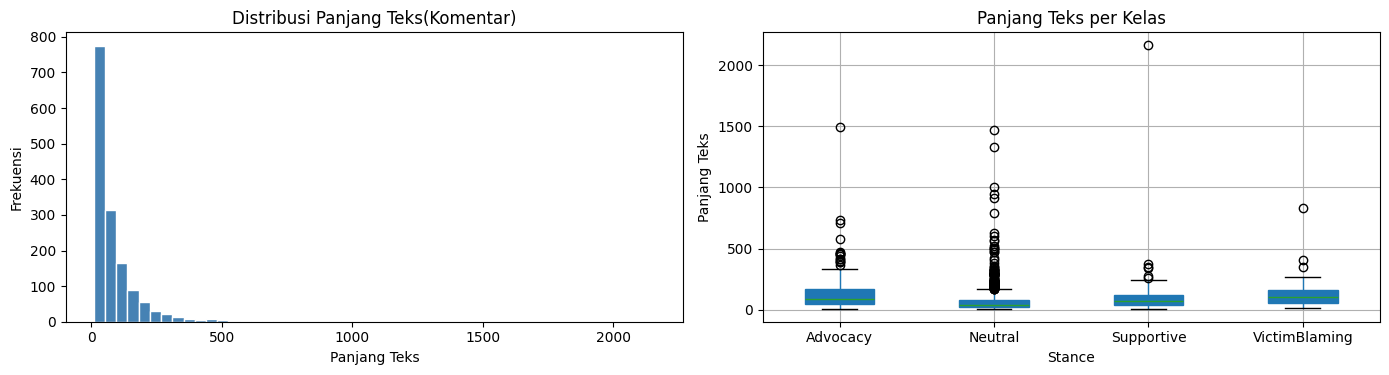

count    1500.000000
mean       88.553333
std       128.391425
min        10.000000
25%        28.000000
50%        51.000000
75%       103.000000
max      2160.000000
Name: panjangData, dtype: float64


In [32]:
data['panjangData'] = data['text'].apply(len)

fig,axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(data['panjangData'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Panjang Teks(Komentar)', fontsize=12)
axes[0].set_xlabel('Panjang Teks')
axes[0].set_ylabel('Frekuensi')

data.boxplot(column='panjangData',by='stance',ax=axes[1],patch_artist=True)
axes[1].set_title('Panjang Teks per Kelas',fontsize=12)
axes[1].set_xlabel('Stance')
axes[1].set_ylabel('Panjang Teks')
plt.suptitle('')

plt.tight_layout()
plt.show()
print(data['panjangData'].describe())

## 4. DATA CLEANING


In [33]:
slangIndonesia = [
    (r'\bkalo ga\b','kalau tidak'),(r'\bkalo gak\b','kalau tidak'),
    (r'\bgabisa\b','tidak bisa'),(r'\bgatau\b','tidak tahu'),
    (r'\bgtau\b','tidak tahu'),(r'\bgada\b','tidak ada'),
    (r'\bgaada\b','tidak ada'),(r'\bgakuat\b','tidak kuat'),
    (r'\bkaga\b','tidak'),(r'\bngga\b','tidak'),(r'\bnggak\b','tidak'),
    (r'\bnggk\b','tidak'),(r'\bgak\b','tidak'),(r'\bgk\b','tidak'),
    (r'\bga\b','tidak'),(r'\bkgk\b','tidak'),(r'\bnga\b','tidak'),
    (r'\bbngt\b','banget'),(r'\bbngeet\b','banget'),(r'\bbangeett\b','banget'),
    (r'\bbangettt\b','banget'),(r'\bbangett\b','banget'),
    (r'\bbgtt\b','banget'),(r'\bbgt\b','banget'),
    (r'\bampek\b','sampai'),(r'\bsampe\b','sampai'),(r'\bsmpe\b','sampai'),
    (r'\bampe\b','sampai'),(r'\bskrng\b','sekarang'),(r'\bskrg\b','sekarang'),
    (r'\bsudh\b','sudah'),(r'\budah\b','sudah'),(r'\budh\b','sudah'),
    (r'\buda\b','sudah'),(r'\bsdh\b','sudah'),(r'\btrss\b','terus'),
    (r'\btrs\b','terus'),(r'\bdpet\b','dapat'),(r'\bdapet\b','dapat'),
    (r'\bdpt\b','dapat'),(r'\bblum\b','belum'),(r'\bblm\b','belum'),
    (r'\bpakek\b','pakai'),(r'\bpake\b','pakai'),(r'\bpke\b','pakai'),
    (r'\bFakyltas\b','fakultas'),(r'\bkrena\b','karena'),(r'\bkrna\b','karena'),
    (r'\bkarna\b','karena'),(r'\bkrn\b','karena'),(r'\bkayak\b','seperti'),
    (r'\bkaya\b','seperti'),(r'\bkyk\b','seperti'),(r'\bkek\b','seperti'),
    (r'\bkalo\b','kalau'),(r'\bklo\b','kalau'),(r'\bklu\b','kalau'),
    (r'\bkl\b','kalau'),(r'\btapii\b','tapi'),(r'\btpi\b','tapi'),
    (r'\btp\b','tapi'),(r'\bjugaa\b','juga'),(r'\bjga\b','juga'),
    (r'\bjg\b','juga'),(r'\byng\b','yang'),(r'\byg\b','yang'),
    (r'\bdgn\b','dengan'),(r'\bdrpd\b','daripada'),(r'\bdr\b','dari'),
    (r'\bmsih\b','masih'),(r'\bmsh\b','masih'),(r'\bmnurut\b','menurut'),
    (r'\bmnrt\b','menurut'),(r'\bmrk\b','mereka'),(r'\bbnyk\b','banyak'),
    (r'\bbyk\b','banyak'),(r'\bgmna\b','bagaimana'),(r'\bgimana\b','bagaimana'),
    (r'\bgmn\b','bagaimana'),(r'\bknapa\b','kenapa'),(r'\bknp\b','kenapa'),
    (r'\bpdhal\b','padahal'),(r'\bpdhl\b','padahal'),(r'\bspt\b','seperti'),
    (r'\bsm\b','sama'),(r'\baj\b','saja'),(r'\byuk\b','ayo'),
    (r'\bantemono\b','pukul'),(r'\bsj\b','saja'),(r'\bmna\b','mana'),
    (r'\bmn\b','mana'),(r'\bmnghukum\b','menghukum'),(r'\bkluarin\b','keluarkan'),
    (r'\bbkn\b','bukan'),(r'\bank\b','anak'),(r'\bemane\b','sayang'),
    (r'\bthx\b','terima kasih'),(r'\butk\b','untuk'),(r'\btruz\b','terus'),
    (r'\bfhui\b','fakultas hukum universitas indonesia'),
    (r'\bfh ui\b','fakultas hukum universitas indonesia'),
    (r'\bfh\b','fakultas hukum'),(r'\bui\b','universitas indonesia'),
    (r'\bks\b','kekerasan seksual'),(r'\bdo\b','drop out'),
    (r'\bppks\b','satgas kekerasan seksual'),(r'\bptn\b','perguruan tinggi negeri'),
    (r'\bpubspeak\b','public speaking'),
    (r'\bplisss\b',''),(r'\bpliss\b',''),(r'\bplis\b',''),(r'\bpls\b',''),
    (r'\banjirr\b',''),(r'\banjir\b',''),(r'\bnjirr\b',''),(r'\bnjir\b',''),
    (r'\banjg\b',''),(r'\banj\b',''),(r'\bjirr\b',''),(r'\bjir\b',''),
    (r'\bwkwkwkwk\b',''),(r'\bwkwkwk\b',''),(r'\bwkwk\b',''),
    (r'\bhahahaha\b',''),(r'\bhahaha\b',''),(r'\bhaha\b',''),
    (r'\bhehe\b',''),(r'\bhihi\b',''),(r'\blmao\b',''),(r'\blol\b',''),
    (r'\bwtf\b',''),(r'\bomg\b',''),(r'\bwth\b',''),
    (r'\bcok\b',''),(r'\bcuy\b',''),(r'\bwoy\b',''),(r'\bwoi\b',''),
    (r'\bih\b',''),(r'\bcih\b',''),(r'\bbtw\b',''),(r'\bfyi\b',''),
    (r'\bcmiiw\b',''),(r'\bcmww\b',''),(r'\bokk\b',''),(r'\boke\b',''),
    (r'\bsih\b',''),(r'\bnih\b',''),(r'\bdong\b',''),
    (r'\bdeh\b',''),(r'\bkok\b',''),(r'\bkan\b',''),
    (r'\blah\b',''),(r'\byah\b',''),(r'\byaa\b',''),
    (r'\bnah\b',''),(r'\beh\b',''),(r'\bahh\b',''),
    (r'\buhh\b',''),(r'\bah\b',''),
]

factory  = StopWordRemoverFactory()
sastrawi = set(factory.get_stop_words())

kataDomain = {
    'korban','pelaku','pelecehan','kekerasan','seksual',
    'perempuan','wanita','cewe','cewek',
    'hukum','kampus','universitas','dosen','mahasiswa','mahasiswi',
    'keadilan','trauma','consent','verbal',
    'grup','chat','speak','drop','out',
    'moral','adab','etika',
    'tidak','bukan','belum','jangan','tanpa',
    'sedih','marah','kecewa','malu','miris','sakit','hancur',
    'berani','salut','bangga','keren','hebat','solid',
    'semangat','dukung','bela','lindungi','aman',
    'proses','sanksi','hukuman','sidang','investigasi',
    'kasus','inside','joke','jokes','template','objektifikasi',
    'normalisasi','penegak','bisa','mau','tahu','ada',
}

kataTambahan = {
    'kak','bang','nih','sih','dong','deh','aja',
    'udah','ga','gak','nggak','aku','gue','gua','gw',
    'lu','lo','elu','elo','kamu','dia','mereka','kita','kami',
    'itu','ini','jadi','kan','lah','kok',
    'ya','yaa','yah','eh','ah','oh',
    'sticker','fyp','tiktok','like','follow','share',
}

stopWords = (sastrawi.union(kataTambahan)) - kataDomain

def normalisasiSlang(text):
    for x, y in slangIndonesia:
        text = re.sub(x, y, text, flags=re.IGNORECASE)
    return text

def cleanText(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'\brt\b', '', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = normalisasiSlang(text)
    text = emoji.demojize(text, language='id')
    text = text.replace(':', ' ').replace('_', ' ')
    text = re.sub(r'[^a-z\s\.\,\!\?]', ' ', text)
    text = re.sub(r'([.,!?])', r' \1 ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def hapusStopWords(text):
    words    = text.split()
    filtered = [w for w in words if w.lower() not in stopWords or w.lower() in kataDomain]
    return ' '.join(filtered)

def final(text):
    clean = cleanText(text)
    rmv   = hapusStopWords(clean)
    return ' '.join([w for w in rmv.split() if len(w) > 1])

In [34]:
data['CleanText'] = data['text'].apply(final)
data = data[data['CleanText'].str.strip() != ''].reset_index(drop=True)

len(data)

1496

## 5. ENCODE LABELS

In [35]:
label = {
    'Supportive' : 0,
    'VictimBlaming' : 1,
    'Neutral': 2,
    'Advocacy': 3

}
label_names = ['Supportive', 'VictimBlaming', 'Neutral', 'Advocacy']
data['label'] = data['stance'].map(label)
data['label'].value_counts()

,count
label,
2,1104
3,210
0,129
1,53


## 6. TRAIN AND VALIDATION

Train: 1196  |  Val: 300


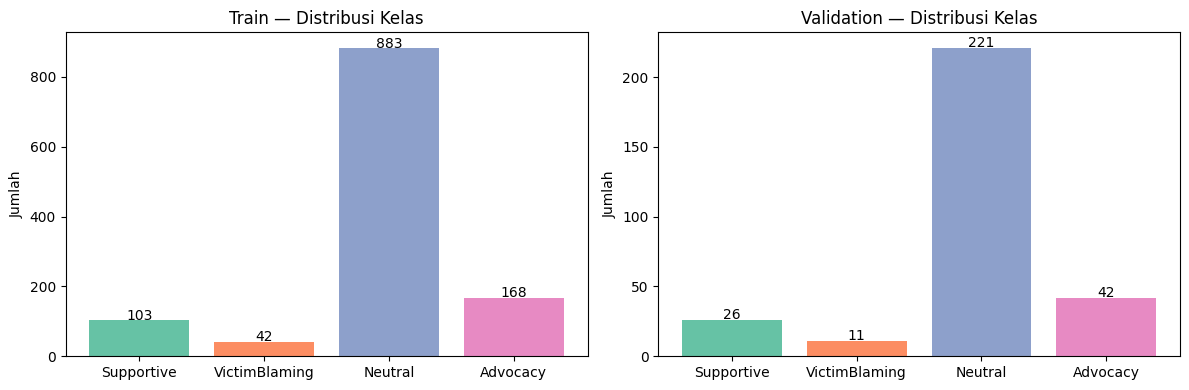

In [36]:
TrainData,ValData = train_test_split(
    data, test_size=0.2, random_state=42, stratify=data['label']
)
TrainData = TrainData.reset_index(drop=True)
ValData   = ValData.reset_index(drop=True)

print(f'Train: {len(TrainData)}  |  Val: {len(ValData)}')


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, title in zip(axes,[TrainData, ValData], ['Train', 'Validation']):
    counts = data['label'].value_counts().sort_index()
    ax.bar([label_names[i] for i in counts.index], counts.values,
           color=sns.color_palette('Set2', 4))
    ax.set_title(f'{title} — Distribusi Kelas')
    ax.set_ylabel('Jumlah')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.5, str(v), ha='center')
plt.tight_layout()
plt.show()

In [37]:
class_weights_arr    = compute_class_weight('balanced',
                           classes=np.unique(TrainData['label'].values),
                           y=TrainData['label'].values)
class_weights_tensor = torch.tensor(class_weights_arr, dtype=torch.float)

print('Class weights:')
for name, w in zip(label_names, class_weights_arr):
    print(f'  {name:15s} = {w:.4f}')

Class weights:
  Supportive      = 2.9029
  VictimBlaming   = 7.1190
  Neutral         = 0.3386
  Advocacy        = 1.7798


## 7. TOKENIZATION

In [38]:
from transformers import AutoTokenizer

MAX_LENGTH = 128

tokenizer_base  = AutoTokenizer.from_pretrained('indolem/indobert-base-uncased')
tokenizer_tweet = AutoTokenizer.from_pretrained('indolem/indobertweet-base-uncased')

dataset_raw = DatasetDict({
    'train': Dataset.from_pandas(TrainData[['CleanText', 'label']]),
    'val'  : Dataset.from_pandas(ValData[['CleanText', 'label']]),
})

def make_tokenize_fn(tokenizer):
    def _fn(examples):
        return tokenizer(
            examples['CleanText'],
            padding='max_length',
            truncation=True,
            max_length=MAX_LENGTH
        )
    return _fn

tokenized_base  = dataset_raw.map(make_tokenize_fn(tokenizer_base),  batched=True)
tokenized_tweet = dataset_raw.map(make_tokenize_fn(tokenizer_tweet), batched=True)

print('Tokenisation Selesai')
print('Feature keys:', tokenized_base['train'].column_names)

Map:   0%|          | 0/1196 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/1196 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Tokenisation Selesai
Feature keys: ['CleanText', 'label', 'input_ids', 'token_type_ids', 'attention_mask']


## 8. MODELLING

In [39]:
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits
        weight  = class_weights_tensor.to(model.device)
        loss_fn = nn.CrossEntropyLoss(weight=weight)
        loss    = loss_fn(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy'   : accuracy_score(labels, preds),
        'f1_macro'   : f1_score(labels, preds, average='macro'),
        'f1_weighted': f1_score(labels, preds, average='weighted'),
    }


def make_training_args(output_dir):
    return TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=15,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        warmup_ratio=0.1,
        lr_scheduler_type='cosine',
        weight_decay=0.01,
        logging_dir=output_dir + '/logs',
        logging_steps=10,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        disable_tqdm=True,
    )

## 9. TRAINING

In [40]:
print('=' * 55)
print('  Training Model 1 — IndoBERT Base')
print('=' * 55)

model_base = AutoModelForSequenceClassification.from_pretrained(
    'indolem/indobert-base-uncased', num_labels=4
)

trainer_base = CustomTrainer(
    model=model_base,
    args=make_training_args('./results_base'),
    train_dataset=tokenized_base['train'],
    eval_dataset=tokenized_base['val'],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)
trainer_base.train()

  Training Model 1 — IndoBERT Base


Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 116, in auto_conversion
    raise e
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 95, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 71, in get_conversion_pr_reference
    spawn_conversion(token, private, model_id)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 48, in spawn_con

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecate

{'loss': '1.385', 'grad_norm': '33.44', 'learning_rate': '3.982e-06', 'epoch': '0.1333'}
{'loss': '1.394', 'grad_norm': '44.47', 'learning_rate': '8.407e-06', 'epoch': '0.2667'}
{'loss': '1.417', 'grad_norm': '26.49', 'learning_rate': '1.283e-05', 'epoch': '0.4'}
{'loss': '1.361', 'grad_norm': '20.21', 'learning_rate': '1.726e-05', 'epoch': '0.5333'}
{'loss': '1.525', 'grad_norm': '23.65', 'learning_rate': '2.168e-05', 'epoch': '0.6667'}
{'loss': '1.375', 'grad_norm': '21.64', 'learning_rate': '2.611e-05', 'epoch': '0.8'}
{'loss': '1.394', 'grad_norm': '44.26', 'learning_rate': '3.053e-05', 'epoch': '0.9333'}
{'eval_loss': '1.384', 'eval_accuracy': '0.56', 'eval_f1_macro': '0.3389', 'eval_f1_weighted': '0.5873', 'eval_runtime': '2.469', 'eval_samples_per_second': '121.5', 'eval_steps_per_second': '7.697', 'epoch': '1'}


...

{'loss': '0.1282', 'grad_norm': '26.35', 'learning_rate': '2.037e-05', 'epoch': '9.067'}
{'loss': '0.02786', 'grad_norm': '0.4229', 'learning_rate': '1.961e-05', 'epoch': '9.2'}
{'loss': '0.09755', 'grad_norm': '56.97', 'learning_rate': '1.885e-05', 'epoch': '9.333'}
{'loss': '0.1854', 'grad_norm': '6.972', 'learning_rate': '1.811e-05', 'epoch': '9.467'}
{'loss': '0.04184', 'grad_norm': '2.981', 'learning_rate': '1.736e-05', 'epoch': '9.6'}
{'loss': '0.1663', 'grad_norm': '58.18', 'learning_rate': '1.663e-05', 'epoch': '9.733'}
{'loss': '0.04344', 'grad_norm': '0.2444', 'learning_rate': '1.59e-05', 'epoch': '9.867'}
{'loss': '0.1236', 'grad_norm': '54.59', 'learning_rate': '1.518e-05', 'epoch': '10'}
{'eval_loss': '3.304', 'eval_accuracy': '0.74', 'eval_f1_macro': '0.46', 'eval_f1_weighted': '0.7286', 'eval_runtime': '2.922', 'eval_samples_per_second': '102.7', 'eval_steps_per_second': '6.502', 'epoch': '10'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'train_runtime': '426.1', 'train_samples_per_second': '42.1', 'train_steps_per_second': '2.64', 'train_loss': '0.7959', 'epoch': '10'}


TrainOutput(global_step=750, training_loss=0.7958691383997599, metrics={'train_runtime': 426.133, 'train_samples_per_second': 42.1, 'train_steps_per_second': 2.64, 'train_loss': 0.7958691383997599, 'epoch': 10.0})

In [41]:
print('=' * 55)
print('  Training Model 2 — IndoBERTweet')
print('=' * 55)

model_tweet = AutoModelForSequenceClassification.from_pretrained(
    'indolem/indobertweet-base-uncased', num_labels=4
)

trainer_tweet = CustomTrainer(
    model=model_tweet,
    args=make_training_args('./results_tweet'),
    train_dataset=tokenized_tweet['train'],
    eval_dataset=tokenized_tweet['val'],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)
trainer_tweet.train()

  Training Model 2 — IndoBERTweet


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is depre

{'loss': '1.409', 'grad_norm': '10.08', 'learning_rate': '3.982e-06', 'epoch': '0.1333'}
{'loss': '1.42', 'grad_norm': '14.42', 'learning_rate': '8.407e-06', 'epoch': '0.2667'}
{'loss': '1.371', 'grad_norm': '10.02', 'learning_rate': '1.283e-05', 'epoch': '0.4'}
{'loss': '1.293', 'grad_norm': '10.27', 'learning_rate': '1.726e-05', 'epoch': '0.5333'}
{'loss': '1.386', 'grad_norm': '11.78', 'learning_rate': '2.168e-05', 'epoch': '0.6667'}
{'loss': '1.321', 'grad_norm': '10.87', 'learning_rate': '2.611e-05', 'epoch': '0.8'}
{'loss': '1.175', 'grad_norm': '9.666', 'learning_rate': '3.053e-05', 'epoch': '0.9333'}
{'eval_loss': '1.14', 'eval_accuracy': '0.6133', 'eval_f1_macro': '0.4243', 'eval_f1_weighted': '0.6425', 'eval_runtime': '2.608', 'eval_samples_per_second': '115', 'eval_steps_per_second': '7.285', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

{'loss': '0.004317', 'grad_norm': '0.0433', 'learning_rate': '3.189e-05', 'epoch': '7.067'}
{'loss': '0.0998', 'grad_norm': '0.01886', 'learning_rate': '3.115e-05', 'epoch': '7.2'}
{'loss': '0.0285', 'grad_norm': '0.1224', 'learning_rate': '3.039e-05', 'epoch': '7.333'}
{'loss': '0.08739', 'grad_norm': '0.09774', 'learning_rate': '2.963e-05', 'epoch': '7.467'}
{'loss': '0.04601', 'grad_norm': '0.0629', 'learning_rate': '2.886e-05', 'epoch': '7.6'}
{'loss': '0.07545', 'grad_norm': '4.753', 'learning_rate': '2.81e-05', 'epoch': '7.733'}
{'loss': '0.01192', 'grad_norm': '0.01902', 'learning_rate': '2.732e-05', 'epoch': '7.867'}
{'loss': '0.1155', 'grad_norm': '0.02738', 'learning_rate': '2.655e-05', 'epoch': '8'}
{'eval_loss': '2.798', 'eval_accuracy': '0.8033', 'eval_f1_macro': '0.515', 'eval_f1_weighted': '0.7876', 'eval_runtime': '2.589', 'eval_samples_per_second': '115.9', 'eval_steps_per_second': '7.34', 'epoch': '8'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'train_runtime': '573.6', 'train_samples_per_second': '31.28', 'train_steps_per_second': '1.961', 'train_loss': '0.5008', 'epoch': '8'}


TrainOutput(global_step=600, training_loss=0.5008387634965281, metrics={'train_runtime': 573.5723, 'train_samples_per_second': 31.278, 'train_steps_per_second': 1.961, 'train_loss': 0.5008387634965281, 'epoch': 8.0})

## 10. TRAINING CURVES

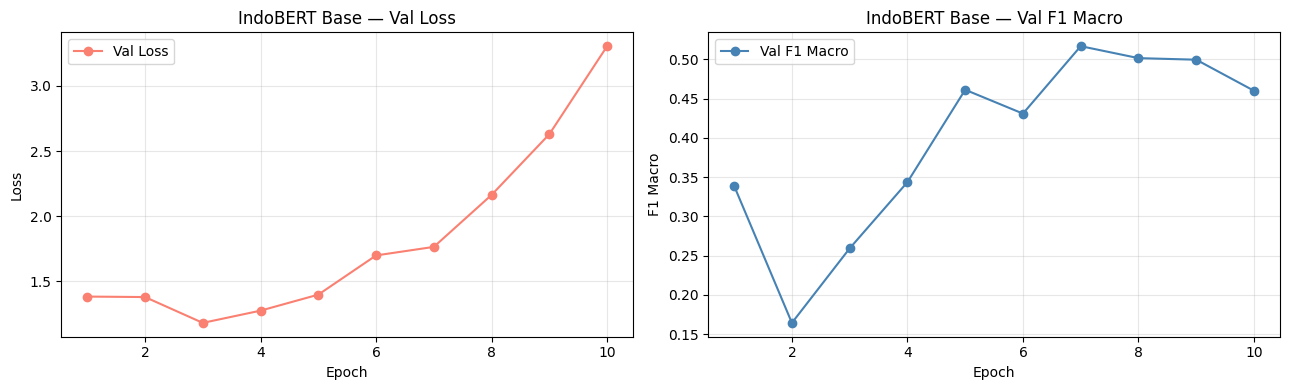

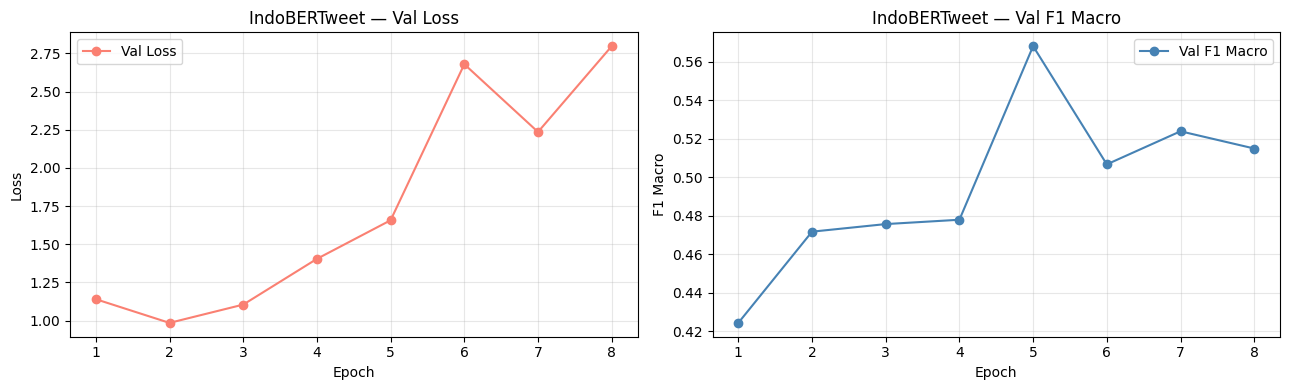

In [42]:
def extract_history(trainer):
    epochs, losses, f1s = [], [], []
    for entry in trainer.state.log_history:
        if 'eval_loss' in entry and 'eval_f1_macro' in entry:
            epochs.append(entry.get('epoch', len(epochs) + 1))
            losses.append(entry['eval_loss'])
            f1s.append(entry['eval_f1_macro'])
    return epochs, losses, f1s


def plot_history(trainer, title):
    epochs, losses, f1s = extract_history(trainer)
    if not epochs:
        print(f'none(tidak tersedia) {title}')
        return
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(epochs, losses, marker='o', color='salmon',    label='Val Loss')
    axes[0].set_title(f'{title} — Val Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, f1s,    marker='o', color='steelblue', label='Val F1 Macro')
    axes[1].set_title(f'{title} — Val F1 Macro')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1 Macro')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


plot_history(trainer_base,  'IndoBERT Base')
plot_history(trainer_tweet, 'IndoBERTweet')

## 11. EVALUATION

Hasil Eval: IndoBERT Base
Accuracy: 0.7500
Balanced Accuracy: 0.5199(lebih adil untuk data imbalanced)
F1 Macro: 0.5168
F1 Weighted: 0.7471
Cohen's Kappa: 0.4353
               precision    recall  f1-score   support

   Supportive     0.5333    0.3077    0.3902        26
VictimBlaming     0.4000    0.1818    0.2500        11
      Neutral     0.8632    0.8281    0.8453       221
     Advocacy     0.4706    0.7619    0.5818        42

     accuracy                         0.7500       300
    macro avg     0.5668    0.5199    0.5168       300
 weighted avg     0.7627    0.7500    0.7471       300



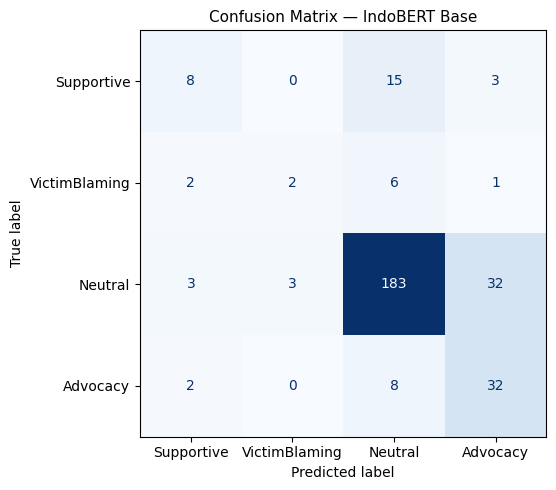

Hasil Eval: IndoBERTweet
Accuracy: 0.7967
Balanced Accuracy: 0.5648(lebih adil untuk data imbalanced)
F1 Macro: 0.5708
F1 Weighted: 0.7923
Cohen's Kappa: 0.5216
               precision    recall  f1-score   support

   Supportive     0.4444    0.4615    0.4528        26
VictimBlaming     0.4000    0.1818    0.2500        11
      Neutral     0.8739    0.8778    0.8758       221
     Advocacy     0.6739    0.7381    0.7045        42

     accuracy                         0.7967       300
    macro avg     0.5981    0.5648    0.5708       300
 weighted avg     0.7913    0.7967    0.7923       300



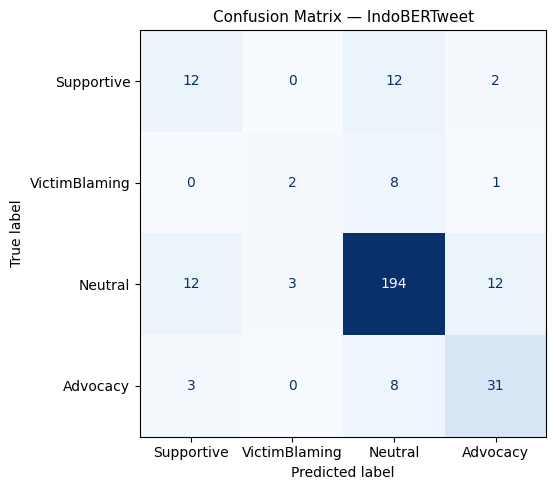

In [43]:
def evaluate_model(trainer, tokenized_ds, model_name):
    preds_out = trainer.predict(tokenized_ds['val'])
    y_pred    = np.argmax(preds_out.predictions, axis=1)
    y_true    = preds_out.label_ids
    acc    = accuracy_score(y_true, y_pred)
    b_acc  = balanced_accuracy_score(y_true, y_pred)
    f1_mac = f1_score(y_true, y_pred, average='macro')
    f1_wt  = f1_score(y_true, y_pred, average='weighted')
    kappa  = cohen_kappa_score(y_true, y_pred)

    print(f'Hasil Eval: {model_name}')
    print(f'Accuracy: {acc:.4f}')
    print(f'Balanced Accuracy: {b_acc:.4f}(lebih adil untuk data imbalanced)')
    print(f'F1 Macro: {f1_mac:.4f}')
    print(f'F1 Weighted: {f1_wt:.4f}')
    print(f"Cohen's Kappa: {kappa:.4f}")
    print(classification_report(y_true, y_pred,target_names=label_names, digits=4))

    cm   = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])
    fig, ax = plt.subplots(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=11)
    plt.tight_layout(); plt.show()

    return {'model': model_name, 'acc': acc, 'b_acc': b_acc,
            'f1_macro': f1_mac, 'f1_weighted': f1_wt, 'kappa': kappa}


all_results = []
r1 = evaluate_model(trainer_base,tokenized_base,'IndoBERT Base')
all_results.append(r1)
r2 = evaluate_model(trainer_tweet,tokenized_tweet,'IndoBERTweet')
all_results.append(r2)

## 12. MODEL COMPARISON

                  acc   b_acc  f1_macro  f1_weighted   kappa
model                                                       
IndoBERT Base  0.7500  0.5199    0.5168       0.7471  0.4353
IndoBERTweet   0.7967  0.5648    0.5708       0.7923  0.5216


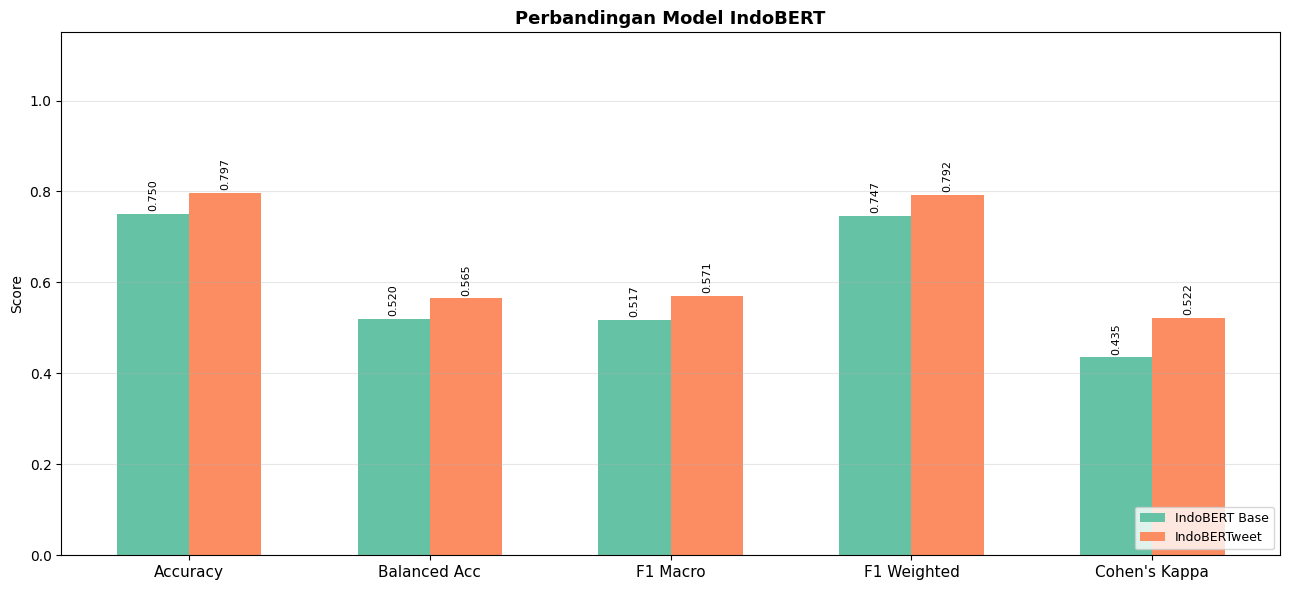


Best model (Macro F1): IndoBERTweet — 0.5708


In [44]:
df_results = pd.DataFrame(all_results).set_index('model')
print(df_results.round(4).to_string())

metrics       = ['acc','b_acc','f1_macro','f1_weighted','kappa']
metric_labels = ['Accuracy','Balanced Acc','F1 Macro','F1 Weighted',"Cohen's Kappa"]

x= np.arange(len(metrics))
width= 0.3
palette=sns.color_palette('Set2',len(df_results))

fig,ax = plt.subplots(figsize=(13, 6))
for i,(model_name, row) in enumerate(df_results.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width=width,
                  label=model_name, color=palette[i])
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2, rotation=90)

ax.set_xticks(x + width * (len(df_results) - 1) / 2)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Model IndoBERT', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

best = df_results['f1_macro'].idxmax()
print(f'\nBest model (Macro F1): {best} — {df_results.loc[best, "f1_macro"]:.4f}')

## 13. SAVE MODELS

In [45]:
saveModel = '/content/drive/MyDrive/Gemastik/Models'
os.makedirs(saveModel, exist_ok=True)

model_base.save_pretrained(os.path.join(saveModel, 'indobert_base'))
model_tweet.save_pretrained(os.path.join(saveModel, 'indobertweet'))
tokenizer_base.save_pretrained(os.path.join(saveModel, 'tokenizer_base'))
tokenizer_tweet.save_pretrained(os.path.join(saveModel, 'tokenizer_tweet'))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/Gemastik/Models/tokenizer_tweet/tokenizer_config.json',
 '/content/drive/MyDrive/Gemastik/Models/tokenizer_tweet/tokenizer.json')

## 14. MODEL INFERENCE

In [48]:
def predict_stance(raw_texts, model, tokenizer, max_length=128):
    model.eval()
    cleaned = [final(t) for t in raw_texts]
    enc     = tokenizer(
        cleaned,
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )
    device = next(model.parameters()).device
    enc    = {k: v.to(device) for k, v in enc.items()}

    with torch.no_grad():
        logits = model(**enc).logits
    probs = torch.softmax(logits, dim=-1).cpu().numpy()
    preds = np.argmax(probs, axis=1)

    out = pd.DataFrame({'raw_text': raw_texts, 'cleaned': cleaned,
                        'predicted_stance': [label_names[p] for p in preds]})
    for i, name in enumerate(label_names):
        out[f'prob_{name}'] = probs[:, i].round(4)
    return out

sample_texts = [
    'drop out aja mahasiswanya gak usah pake acara sidang',
    'semangat ya kalian, korban berhak dapat keadilan',
    'ada apa nih kok ramai banget',
    'pelakunya biadab dan bejat, harus dihukum berat',
    'siapa suruh pakai pakaian ketat malam-malam',
    'melecehkan dari mananya sih, lebay banget',
    'fakultas hukum harus segera proses kasusnya',
    'peluk jauh buat para korban, kalian tidak sendiri',
]

print('--- Model 1: IndoBERT Base ---')
res1 = predict_stance(sample_texts, model_base, tokenizer_base)
print(res1[['raw_text', 'predicted_stance']].to_string(index=False))

print('\--- Model 2: IndoBERTweet ---')
res2 = predict_stance(sample_texts, model_tweet, tokenizer_tweet)
print(res2[['raw_text', 'predicted_stance']].to_string(index=False))

--- Model 1: IndoBERT Base ---
                                            raw_text predicted_stance
drop out aja mahasiswanya gak usah pake acara sidang         Advocacy
    semangat ya kalian, korban berhak dapat keadilan         Advocacy
                        ada apa nih kok ramai banget          Neutral
     pelakunya biadab dan bejat, harus dihukum berat         Advocacy
         siapa suruh pakai pakaian ketat malam-malam          Neutral
           melecehkan dari mananya sih, lebay banget          Neutral
         fakultas hukum harus segera proses kasusnya         Advocacy
   peluk jauh buat para korban, kalian tidak sendiri          Neutral
\--- Model 2: IndoBERTweet ---
                                            raw_text predicted_stance
drop out aja mahasiswanya gak usah pake acara sidang         Advocacy
    semangat ya kalian, korban berhak dapat keadilan       Supportive
                        ada apa nih kok ramai banget          Neutral
     pelakunya biadab dan be

<>:40: SyntaxWarning: invalid escape sequence '\-'
<>:40: SyntaxWarning: invalid escape sequence '\-'
/tmp/ipykernel_2976/1944477025.py:40: SyntaxWarning: invalid escape sequence '\-'
  print('\--- Model 2: IndoBERTweet ---')
